In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict, train_test_split
from sklearn.metrics import mean_squared_error, silhouette_score
from sklearn.cluster import KMeans, DBSCAN

In [17]:
data = pd.read_csv('Mall_Customers.csv')

In [18]:
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


<Axes: xlabel='count', ylabel='Gender'>

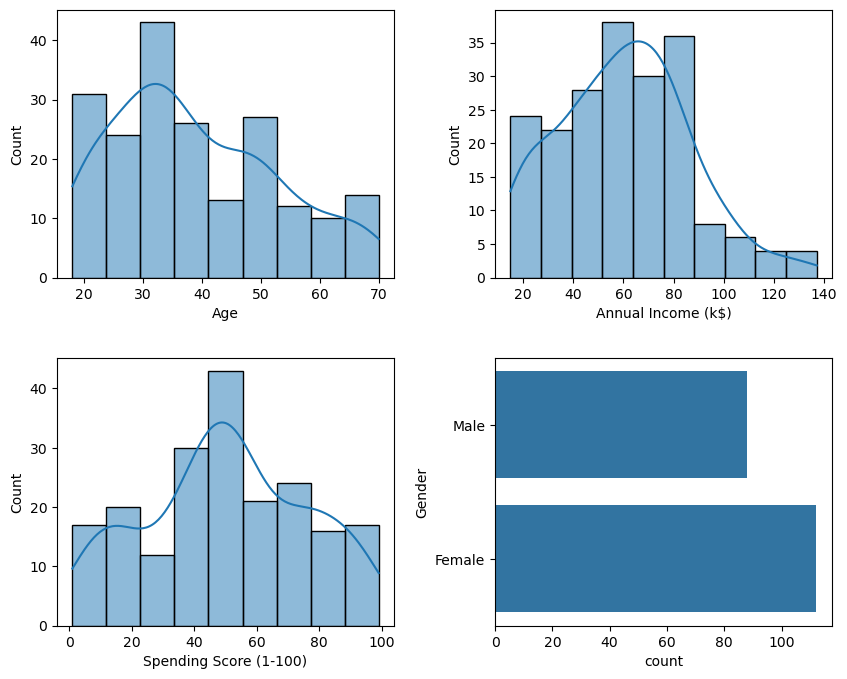

In [73]:
fig, axs = plt.subplots(nrows = 2, ncols = 2)
fig.subplots_adjust(wspace=0.3)
fig.subplots_adjust(hspace=0.3)
fig.set_size_inches(10, 8)

sns.histplot(data['Age'], kde = True, ax = axs[0,0])
sns.histplot(data['Annual Income (k$)'], kde = True, ax = axs[0,1])
sns.histplot(data['Spending Score (1-100)'], kde = True, ax = axs[1,0])
sns.countplot(data['Gender'], ax = axs[1,1])


C:\Users\Sunny\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Sunny\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Sunny\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\Sunny\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Window

For n_clusters = 2 The average silhouette_score is : 0.3848654187182249
For n_clusters = 3 The average silhouette_score is : 0.46761358158775435
For n_clusters = 4 The average silhouette_score is : 0.4931963109249047
For n_clusters = 5 The average silhouette_score is : 0.553931997444648
For n_clusters = 6 The average silhouette_score is : 0.45705720010448403
For n_clusters = 7 The average silhouette_score is : 0.45485522128402084
For n_clusters = 8 The average silhouette_score is : 0.46072786639159125
For n_clusters = 9 The average silhouette_score is : 0.4578527068857916


Text(0.5, 1.0, 'Silhouette Scores')

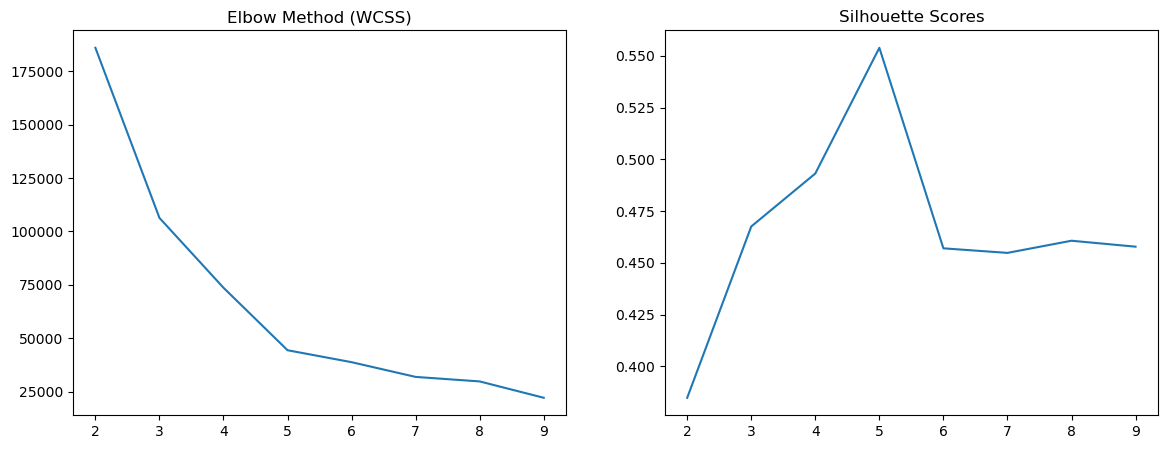

In [70]:
#Q1) Run K-Means for K=2 through K=10 and Q2) Plot elbow curve and silhouette scores
first_pair = data[['Annual Income (k$)', 'Spending Score (1-100)']].values
distance = []
silhouette_scores = []
for i in range(2,10):
    kmeans=KMeans(n_clusters=i, init='k-means++',random_state=0)
    kmeans.fit(first_pair)
    cluster_labels = kmeans.predict(first_pair)
    silhouette_avg = silhouette_score(first_pair, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print("For n_clusters =", i, "The average silhouette_score is :", silhouette_avg)
    distance.append(kmeans.inertia_) #inertia_ = to find the wcss value

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(range(2,10), distance)
ax1.set_title('Elbow Method (WCSS)')
ax2.plot(range(2,10), silhouette_scores)
ax2.set_title('Silhouette Scores')

C:\Users\Sunny\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


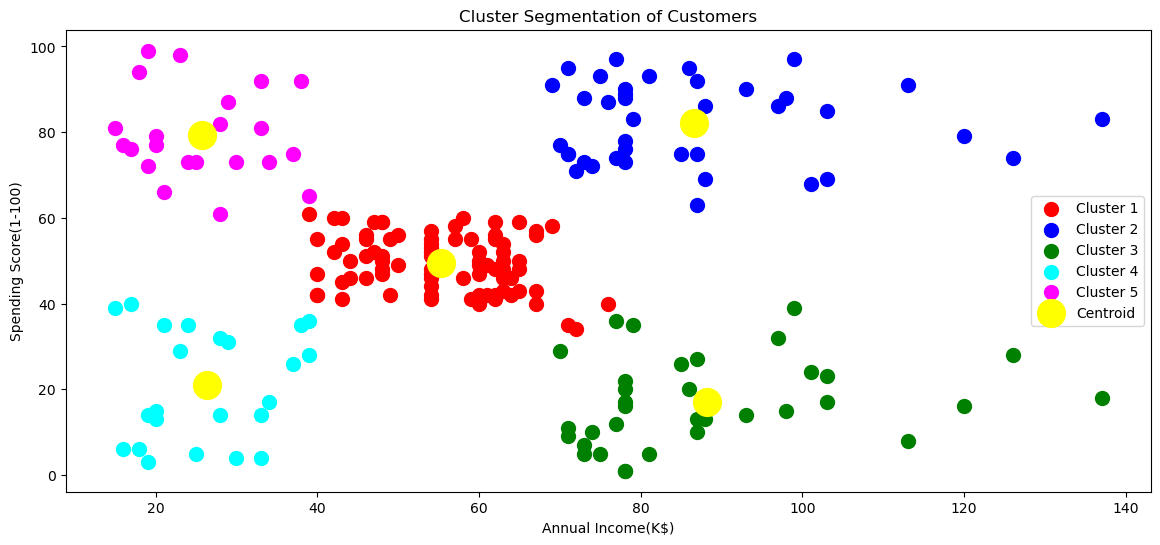

In [36]:
#Q3) Visualize clusters in 2D scatter

kmeans=KMeans(n_clusters=5,init='k-means++',random_state=0)
y_kmeans=kmeans.fit_predict(first_pair)

#plotting the the clusters
fig,ax = plt.subplots(figsize=(14,6))
ax.scatter(first_pair[y_kmeans==0,0],first_pair[y_kmeans==0,1],s=100,c='red',label='Cluster 1')
ax.scatter(first_pair[y_kmeans==1,0],first_pair[y_kmeans==1,1],s=100,c='blue',label='Cluster 2')
ax.scatter(first_pair[y_kmeans==2,0],first_pair[y_kmeans==2,1],s=100,c='green',label='Cluster 3')
ax.scatter(first_pair[y_kmeans==3,0],first_pair[y_kmeans==3,1],s=100,c='cyan',label='Cluster 4')
ax.scatter(first_pair[y_kmeans==4,0],first_pair[y_kmeans==4,1],s=100,c='magenta',label='Cluster 5')

ax.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],s=400,c='yellow',label='Centroid')
plt.title('Cluster Segmentation of Customers')
plt.xlabel('Annual Income(K$)')
plt.ylabel('Spending Score(1-100)')
plt.legend()
plt.show()

In [55]:
def classify(DBSCAN_output):
    if DBSCAN_output == -1:
        return True
    else:
        return False

In [76]:
#Q4) Run DBSCAN and compare which customers it flags as noise (these are outliers)
sc = StandardScaler()
first_pair_scaled = sc.fit_transform(first_pair)
model = DBSCAN(eps=0.5, min_samples=5)
model.fit(first_pair_scaled)

labels = model.labels_
data['DBSCAN_output'] = pd.Series(labels)
data['is_outlier'] = data['DBSCAN_output'].apply(classify)
data.drop(columns = ['DBSCAN_output'], inplace = True)
print(data['is_outlier'].value_counts())
data[data['is_outlier'] == True]

is_outlier
False    192
True       8
Name: count, dtype: int64


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),is_outlier
191,192,Female,32,103,69,True
192,193,Male,33,113,8,True
194,195,Female,47,120,16,True
195,196,Female,35,120,79,True
196,197,Female,45,126,28,True
197,198,Male,32,126,74,True
198,199,Male,32,137,18,True
199,200,Male,30,137,83,True
